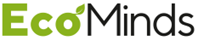

#Topic : Deep Learning for Environmental Impact Analysis. Course : Machine Learning for Environmental Applications

# Workshop: Temperature Prediction with LSTM (Deep Learning)

This notebook predicts the maximum daily temperature using a **Long Short-Term Memory (LSTM)** network. It analyzes a sequence of past days (e.g., the last 14 days) to detect trends (warming/cooling) before making a prediction.

You can adjust key parameters (location coordinates, date ranges, and model hyperparameters) in the setup cells immediately following this header:

# **Ivan Komin**

# **Group: IP-44**

## 1. Configuration & Libraries

In [313]:
# --- CONFIGURATION ---
# Coordinates for target location (e.g., Kropyvnytskyi, Ukraine)
LATITUDE = 48.51
LONGITUDE = 32.25

# Hyperparameters
LOOKBACK_DAYS = 3  # Number of past days the model uses to predict "Tomorrow"
# Historical range to capture enough seasonal cycles and climate trends
START_DATE = "2010-01-01"
END_DATE = "2025-12-31"

# --- Display Period for Graphs (Optional) ---
# Set these to None to show the full range of test data
# Example: To show the last year of data, set it to "2025-01-01" and "2025-12-31"
DISPLAY_START_DATE = "2025-01-01" # Set to None to disable
DISPLAY_END_DATE = "2025-12-31"   # Set to None to disable

CRITICAL_EMERGENCY = 30.0  # Set temperature threshold for critical emergency heatwave (e.g., closing schools, urgent public health warnings)
HEATWAVE_WARNING = 28.0  # Set temperature threshold for heatwave warning (e.g., advising vulnerable groups, issuing heat alerts)

# --- Define the period for this analysis ---
DISPLAY_FORECAST_START_DATE = "2025-08-01"
DISPLAY_FORECAST_END_DATE = "2025-08-31"

print(f"Target Location: Lat={LATITUDE}, Lon={LONGITUDE}")
print(f"Sequence Length (Lookback): {LOOKBACK_DAYS} days")

Target Location: Lat=48.51, Lon=32.25
Sequence Length (Lookback): 3 days


In [314]:
import os
import random
import folium
import nbformat
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully.")

Libraries imported successfully.


In [315]:
def set_seeds(seed=0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Run the function
set_seeds(0)

print("Random seeds set.")

Random seeds set.


In [316]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"✅ GPU Detected: {gpus[0].name}")
else:
    print("⚠️ No GPU detected. Running on CPU.")

⚠️ No GPU detected. Running on CPU.


## 2. Load Data from Open-Meteo

In [317]:
# Construct API URL
URL = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LATITUDE}&longitude={LONGITUDE}&"
    f"start_date={START_DATE}&end_date={END_DATE}&"
    f"daily=temperature_2m_max,shortwave_radiation_sum&"
    f"timezone=auto&format=csv"
)

print("Fetching data from Open-Meteo...")
df = pd.read_csv(URL, skiprows=3)

# Rename columns for clarity
df = df.rename(
    columns={
        "time": "Date",
        "temperature_2m_max (°C)": "MaxTemp",
        "shortwave_radiation_sum (MJ/m²)": "SolarRad",
    }
)

# Drop missing values immediately
df = df.dropna()

print(f"Data loaded: {len(df)} records.")
display(df.head())

Fetching data from Open-Meteo...
Data loaded: 5844 records.


,Date,MaxTemp,SolarRad
0,2010-01-01,0.2,1.85
1,2010-01-02,0.5,1.54
2,2010-01-03,-6.2,3.68
3,2010-01-04,-8.9,3.57
4,2010-01-05,-5.1,4.06


## 3. Preprocessing: Sliding Window for LSTM

LSTMs require input data in the shape: `(Samples, TimeSteps, Features)`.

In [318]:
# 1. Feature Selection
data_values = df[["MaxTemp", "SolarRad"]].values

# 2. Split Data (Preserve Time Order)
# We take the first 80% for training, last 20% for testing
split_index = int(len(data_values) * 0.8)

train_data = data_values[:split_index]
test_data = data_values[split_index:]

# 3. Scaling
# Fit the scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data)

# Transform both sets
train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

# 4. Create Sequences function
def create_sequences(dataset, lookback):
    """
    Converts a 2D array into a 3D array of sequences.
    X shape: (Samples, Lookback, Features)
    y shape: (Samples,)
    """
    X_seq, y_target = [], []
    for i in range(len(dataset) - lookback):
        # Input: Sequence of "lookback" days (all features)
        X_seq.append(dataset[i : i + lookback])
        # Target: The Temp (index 0) of the *next* day
        y_target.append(dataset[i + lookback, 0])
    return np.array(X_seq), np.array(y_target)

# 5. Generate X and y for both sets separately
X_train, y_train = create_sequences(train_scaled, LOOKBACK_DAYS)
X_test, y_test = create_sequences(test_scaled, LOOKBACK_DAYS)

print(f"Input Shape (X_train): {X_train.shape}")
print(f"Target Shape (y_train): {y_train.shape}")

Input Shape (X_train): (4672, 3, 2)
Target Shape (y_train): (4672,)


## 4. Build and Train LSTM Model

In [319]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [320]:
# Define the Model
model = Sequential([
    # Input Shape
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # LSTM Layer
    # return_sequences=False because we only need the final prediction
    LSTM(units=64, return_sequences=False),

    # Regulatization: Dropout
    Dropout(0.2),

    # Output Layer
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                  │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)

In [321]:
print("Starting LSTM training with Early Stopping...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
print("Training complete.")

Starting LSTM training with Early Stopping...
Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0393 - mae: 0.1306 - val_loss: 0.0053 - val_mae: 0.0569
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0077 - mae: 0.0694 - val_loss: 0.0047 - val_mae: 0.0537
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0070 - mae: 0.0665 - val_loss: 0.0045 - val_mae: 0.0541
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0062 - mae: 0.0623 - val_loss: 0.0044 - val_mae: 0.0537
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0057 - mae: 0.0596 - val_loss: 0.0040 - val_mae: 0.0503
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - mae: 0.0599 - val_loss: 0.0040 - val_mae: 0.0504
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 - mae: 0.0585 - val_loss: 0.0039 - val_mae: 0.0491
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0052 - mae: 0.0565 - val_loss: 0.0039 - val_mae: 0.0486
Epoch 9/50

## 5. Visualizing Training Performance

Checking the loss curves helps us understand if the model is overfitting or underfitting.

In [322]:
# Create DataFrame for plotting
history_df = pd.DataFrame({
    "Epoch": history.epoch,
    "Train Loss (MSE)": history.history["loss"],
    "Validation Loss (MSE)": history.history["val_loss"]
})

# Use a colorblind-friendly sequence
fig_hist = px.line(
    history_df,
    x="Epoch",
    y=["Train Loss (MSE)", "Validation Loss (MSE)"],
    title="Model Training History: Loss over Epochs",
    labels={"value": "Mean Squared Error (MSE)", "variable": "Dataset"},
)

# Accessibility: Add line dash patterns to distinguish lines without relying solely on color
fig_hist.update_traces(patch={"line": {"dash": "solid"}}, selector={"name": "Train Loss (MSE)"})
fig_hist.update_traces(patch={"line": {"dash": "dashdot"}}, selector={"name": "Validation Loss (MSE)"})

fig_hist.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Metric:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    yaxis_title="Loss (MSE)"
)

fig_hist.show()

### 📉 How to Read this Graph

This plot shows the "learning curve" of the AI.
- **The Goal:** We want both lines to go **down** over time. This means the model"s error (Loss) is decreasing.
- **Blue Line (Train Loss):** How well the model is learning from the "study material" (historical data).
- **Red Line (Validation Loss):** How well the model performs on "new questions" it hasn"t seen before.

**What to watch for:**
- **Good Result:** Both lines go down and stay close together.
- **Overfitting:** If the Blue line goes down but the Red line starts going **up**, the model is memorizing the data instead of learning patterns.

## 6. Evaluation & Interactive Forecast

### 6a. Model Report Card (Metrics)

In [323]:
# 1. Generate Predictions
predictions_scaled = model.predict(X_test)

# 2. Inverse Scaling logic
# The scaler expects 2 features (Temp, Solar), but we only predicted Temp.
# We must create a dummy array to inverse transform correctly.

# Create placeholder matrices with the same shape as original input (N, 2)
dummy_pred = np.zeros((len(predictions_scaled), 2))
dummy_actual = np.zeros((len(y_test), 2))

# Fill the first column (Temp) with our data
dummy_pred[:, 0] = predictions_scaled.flatten()
dummy_actual[:, 0] = y_test.flatten()

# Inverse transform
pred_inverse = scaler.inverse_transform(dummy_pred)[:, 0]
actual_inverse = scaler.inverse_transform(dummy_actual)[:, 0]

residuals = actual_inverse - pred_inverse

# Calculate the starting date for the test predictions
start_date_for_predictions = pd.to_datetime(df['Date'].iloc[split_index + LOOKBACK_DAYS])
prediction_dates = pd.date_range(start=start_date_for_predictions, periods=len(actual_inverse), freq='D')

# 3. Plotting with Plotly
plot_df = pd.DataFrame(
    {
        "Date": prediction_dates, # Added Date column
        "Actual Temperature": actual_inverse,
        "Predicted Temperature": pred_inverse,
        "Residuals": residuals,
    }
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [324]:
# Calculate standard metrics
mae = mean_absolute_error(actual_inverse, pred_inverse)
rmse = np.sqrt(mean_squared_error(actual_inverse, pred_inverse))
r2 = r2_score(actual_inverse, pred_inverse)

print(f"--- 📊 WEATHER MODEL REPORT CARD ---\n")

# 1. Mean Absolute Error (MAE)
print(f"1. Average Error (MAE): {mae:.2f}°C")
print(f"   👉 Explanation: On average, the model's prediction is off by about {mae:.1f}°C.")
print("-" * 50)

# 2. Root Mean Squared Error (RMSE)
print(f"2. Penalty for Big Mistakes (RMSE): {rmse:.2f}°C")
print("   👉 Explanation: This metric punishes large errors more heavily.")
print("      If this number is much higher than the Average Error, the model occasionally makes big misses.")
print("-" * 50)

# 3. R-Squared Score (R²)
print(f"3. Accuracy Score (R²): {r2:.2f} (or {r2*100:.1f}%)")
print("   👉 Explanation: How much of the temperature variation does the model explain?")
print("      (1.0 = Perfect, 0.0 = Useless, Negative = Worse than guessing)")
if r2 > 0.85:
    print("   ✅ Quality: High Confidence.")
elif r2 > 0.70:
    print("   👍 Quality: Good.")
else:
    print("   ❌ Quality: Low Confidence.")
print("-" * 50)

--- 📊 WEATHER MODEL REPORT CARD ---

1. Average Error (MAE): 2.13°C
   👉 Explanation: On average, the model's prediction is off by about 2.1°C.
--------------------------------------------------
2. Penalty for Big Mistakes (RMSE): 2.78°C
   👉 Explanation: This metric punishes large errors more heavily.
      If this number is much higher than the Average Error, the model occasionally makes big misses.
--------------------------------------------------
3. Accuracy Score (R²): 0.93 (or 92.9%)
   👉 Explanation: How much of the temperature variation does the model explain?
      (1.0 = Perfect, 0.0 = Useless, Negative = Worse than guessing)
   ✅ Quality: High Confidence.
--------------------------------------------------


### 6b. Predictions

We generate predictions on the test set and plot them against actual observations.

In [325]:
# Initialize a Plotly Express line chart for forecast visualization
fig_forecast = px.line(
    plot_df, # Removed .head(365) to show all data
    x="Date", # Use Date column for x-axis
    y=["Actual Temperature", "Predicted Temperature"],
    title="LSTM Model Evaluation: Actual vs. Predicted Temperature",
    labels={
        "value": "Temperature (°C)",
        "variable": "Series",
        "Date": "Date" # Update label for Date axis
    },
)


fig_forecast.update_traces(patch={"line": {"dash": "dashdot", "width": 2}}, selector={"name": "Actual Temperature"})
fig_forecast.update_traces(patch={"line": {"dash": "solid", "width": 2}}, selector={"name": "Predicted Temperature"})

# Set the initial range based on DISPLAY_START_DATE and DISPLAY_END_DATE if they are defined
if DISPLAY_START_DATE and DISPLAY_END_DATE:
    initial_display_range = [DISPLAY_START_DATE, DISPLAY_END_DATE]
else:
    # If not set, use the full range of the test data
    initial_display_range = [plot_df['Date'].min(), plot_df['Date'].max()]

fig_forecast.update_xaxes(
    rangeslider_visible=True,
    range=initial_display_range
)

fig_forecast.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig_forecast.show()

#### 🔮 How to Read this Forecast Graph

This interactive chart compares what really happened against what our AI predicted would happen.

- **Dashed Blue Line (Actual):** The real temperature recordings from the dataset.
- **Red Line (Predicted):** What our LSTM model guessed the temperature would be.
- **Slider (Bottom):** Use the bar at the bottom to zoom in on specific days or scan through the timeline.

**What to watch for:**

- **Synchronization:** Does the red line follow the blue line closely?
- **Lag:** Does the red line react *too late* to sudden temperature spikes? (e.g., the peak is one day late).
- **Amplitude:** Does the model fail to reach the highest highs or lowest lows?

### 6c. Actual vs. Predicted (Goodness of Fit)

In [326]:
fig_scatter = px.scatter(
    plot_df,
    x="Actual Temperature",
    y="Predicted Temperature",
    title="Goodness of Fit (Actual vs. Predicted)",
)

fig_scatter.add_shape(
    type="line",
    x0=plot_df["Actual Temperature"].min(), y0=plot_df["Actual Temperature"].min(),
    x1=plot_df["Predicted Temperature"].max(), y1=plot_df["Actual Temperature"].max(),
    line=dict(color="Red", dash="dash")
)

fig_scatter.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
  )

fig_scatter.show()

#### 🎯 How to Read the Goodness of Fit

This scatter plot helps us see the overall accuracy at a glance, disregarding time.

- **X-Axis:** The Actual Temperature.
- **Y-Axis:** The Predicted Temperature.
- **The Red Dashed Line:** The "Line of Perfection." If a point lands here, the prediction was exactly right.

**What to watch for:**
- **Tight Cluster:** We want the blue dots to hug the red line tightly.
- **Bias:** If most dots are consistently *above* or *below* the red line, the model is biased (consistently guessing too high or too low).
- **Outliers:** Look for lone dots far away from the red line—these are moments where the model was very confused.

### 6d. Residual Plot

In [327]:
# This shows if the model consistently over/under predicts at certain times
fig_resid = px.scatter(
    plot_df,
    x="Date",
    y="Residuals",
    title="Residuals (Error) over Time",
    labels={
        "Residuals": "Error Difference (°C)",
        "Date": "Date"
    },
)

# Add a zero line for reference
fig_resid.add_hline(y=0, line_dash="dash", line_color="Red")

fig_resid.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
  )

fig_resid.show()

#### 📊 How to Read the Residuals Plot

"Residuals" are just a word for **Errors**. It is calculated as `Actual Value - Predicted Value`.

- **The Center Line (zero):** This represents a "Perfect Prediction."
- **Blue Dots:** The error at each specific time step.
- **Above zero:** The model predicted *too low* (Underestimated).
- **Below zero:** The model predicted *too high* (Overestimated).

**What to watch for:**
- **Good Result:** The dots look like random "noise" or static centered around zero.
- **Bad Result:** If you see repeating waves or clear patterns (e.g., it's always high in summer), the model is missing a key pattern in the data (like seasonality).

## 7. Climate-Adaptive Decision System

In [328]:
print("\n--- HEATWAVE EARLY WARNING SYSTEM (LSTM) ---")

# Filter the plot_df for the specified display period
forecast_period_df = plot_df[
    (plot_df['Date'] >= DISPLAY_FORECAST_START_DATE) &
    (plot_df['Date'] <= DISPLAY_FORECAST_END_DATE)
].copy()

# Check the forecast for the specified period
if not forecast_period_df.empty:
    print(f"Analyzing forecast for the period: {DISPLAY_FORECAST_START_DATE} to {DISPLAY_FORECAST_END_DATE}")
    for index, row in forecast_period_df.iterrows():
        forecast_temp = float(row['Predicted Temperature'])
        actual_temp = float(row['Actual Temperature'])
        error = forecast_temp - actual_temp
        forecast_date = row['Date'].strftime('%Y-%m-%d')

        status_icon = "🟢"
        action_msg = "Status Normal."

        if forecast_temp >= CRITICAL_EMERGENCY:
            status_icon = "🔴"
            action_msg = "CRITICAL ALERT! Open cooling centers."
        elif forecast_temp >= HEATWAVE_WARNING:
            status_icon = "🟠"
            action_msg = "ADVISORY. Issue elderly warnings."

        print(
            f"Date: {forecast_date} | Forecast={forecast_temp:.1f}°C | Actual={actual_temp:.1f}°C | Error={error:.1f}°C"
        )
        print(f"  [ACTION]: {status_icon} {action_msg}")
        print("-" * 60)
else:
    print(f"No forecast data available for the period: {DISPLAY_FORECAST_START_DATE} to {DISPLAY_FORECAST_END_DATE}")



--- HEATWAVE EARLY WARNING SYSTEM (LSTM) ---
Analyzing forecast for the period: 2025-08-01 to 2025-08-31
Date: 2025-08-01 | Forecast=26.4°C | Actual=27.0°C | Error=-0.6°C
  [ACTION]: 🟢 Status Normal.
------------------------------------------------------------
Date: 2025-08-02 | Forecast=27.6°C | Actual=28.5°C | Error=-0.9°C
  [ACTION]: 🟢 Status Normal.
------------------------------------------------------------
Date: 2025-08-03 | Forecast=28.2°C | Actual=29.5°C | Error=-1.3°C
  [ACTION]: 🟠 ADVISORY. Issue elderly warnings.
------------------------------------------------------------
Date: 2025-08-04 | Forecast=28.8°C | Actual=30.5°C | Error=-1.7°C
  [ACTION]: 🟠 ADVISORY. Issue elderly warnings.
------------------------------------------------------------
Date: 2025-08-05 | Forecast=29.9°C | Actual=31.2°C | Error=-1.3°C
  [ACTION]: 🟠 ADVISORY. Issue elderly warnings.
------------------------------------------------------------
Date: 2025-08-06 | Forecast=30.4°C | Actual=32.5°C | Erro

## 8. Geospatial Visualization

In [329]:
# --- Prepare forecast_data without jitter ---

# Filter the plot_df for the specified display period to get forecast_period_df
# This part assumes 2b30ff42 has already been run and produced forecast_period_df
forecast_period_df = plot_df[
    (plot_df['Date'] >= DISPLAY_FORECAST_START_DATE) &
    (plot_df['Date'] <= DISPLAY_FORECAST_END_DATE)
].copy()

if not forecast_period_df.empty:
    num_forecast_days = len(forecast_period_df)

    # Create forecast_data without jittering coordinates
    forecast_data = pd.DataFrame({
        'date': forecast_period_df['Date'],
        'lat': [LATITUDE] * num_forecast_days, # Use constant LATITUDE
        'lon': [LONGITUDE] * num_forecast_days, # Use constant LONGITUDE
        'forecast_temp': forecast_period_df['Predicted Temperature'],
        'actual_temp': forecast_period_df['Actual Temperature']
    })
    print(f"'forecast_data' created for {num_forecast_days} days at Lat={LATITUDE}, Lon={LONGITUDE}.")
else:
    print(f"No forecast data available for the period: {DISPLAY_FORECAST_START_DATE} to {DISPLAY_FORECAST_END_DATE}. 'forecast_data' will be empty.")
    forecast_data = pd.DataFrame() # Ensure forecast_data is an empty DataFrame to avoid errors downstream

'forecast_data' created for 31 days at Lat=48.51, Lon=32.25.


In [330]:
# Ensure forecast_data is available and up-to-date for August
# We'll create a 'warning_level' column based on CRITICAL_EMERGENCY and HEATWAVE_WARNING
if 'forecast_temp' in forecast_data.columns:
    forecast_data['warning_level'] = 'Normal value'
    forecast_data.loc[forecast_data['forecast_temp'] >= HEATWAVE_WARNING, 'warning_level'] = 'Heatwave Warning'
    forecast_data.loc[forecast_data['forecast_temp'] >= CRITICAL_EMERGENCY, 'warning_level'] = 'Critical Emergency'

# Convert 'date' column to string format for animation_frame to display only date
forecast_data['date_display'] = forecast_data['date'].dt.strftime('%Y-%m-%d')

# Define a discrete color map for the warning levels
color_map = {
    'Normal value': 'blue',
    'Heatwave Warning': 'orange',
    'Critical Emergency': 'red'
}

# Define the order for categories to ensure correct legend order
category_orders = ['Normal value', 'Heatwave Warning', 'Critical Emergency']

fig = px.scatter_mapbox(forecast_data, lat="lat", lon="lon", color="warning_level",
                        size="forecast_temp", # Size based on forecast_temp
                        hover_name=None, # Removed primary hover_name from 'date'
                        hover_data={"forecast_temp": ':.1f', "date": "|%Y-%m-%d", "warning_level": True, "date_display": False, "lat": False, "lon": False}, # Explicitly hide date_display
                        color_discrete_map=color_map, # Use discrete color map
                        category_orders={"warning_level": category_orders}, # Order categories in legend
                        mapbox_style="open-street-map",
                        zoom=10, height=500,
                        title="Temperature Forecast on Map (Plotly Express)", # Updated title
                        animation_frame="date_display", # Use the new column for animation frame
                        labels={
                            "warning_level": "Warning level",
                            "date_display": "Date"
                        }) # Updated labels

# Update layout to center the map on the configured coordinates
fig.update_layout(mapbox_center={"lat": LATITUDE, "lon": LONGITUDE}, legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ))


fig.show()

## 🗺️ Map as a Decision Support Tool

This interactive map transforms LSTM predictions into actionable insights for risk management:

*   🎯 **Visual Risk:** Red zones immediately highlight where emergency action is needed most.
*   🎯 **Color-Coding:** Instant severity assessment via 🔵 **blue** (normal), 🟠 **orange** (warning), and 🔴 **red** (critical) indicators.
*   🎯 **Proactive Response:** Functions as an early warning system to prepare cooling centers and medical services before the heatwave hits.
*   🎯 **Spatial Awareness:** Helps distinguish between local temperature spikes and broad regional emergencies.
*   🎯 **Clear Communication:** Simplifies complex neural network data into a format that is easy for the public and stakeholders to understand.

## 1. Configuration & Libraries

In [331]:
# --- CONFIGURATION ---
# Coordinates for target location (e.g., Yukon, Canada)
LATITUDE = 64.28
LONGITUDE = -135

# Hyperparameters
LOOKBACK_DAYS = 14  # Number of past days the model uses to predict "Tomorrow"
# Historical range to capture enough seasonal cycles and climate trends
START_DATE = "2010-01-01"
END_DATE = "2025-12-31"

# --- Display Period for Graphs (Optional) ---
# Set these to None to show the full range of test data
# Example: To show the last year of data, set it to "2025-01-01" and "2025-12-31"
DISPLAY_START_DATE = "2025-01-01" # Set to None to disable
DISPLAY_END_DATE = "2025-12-31"   # Set to None to disable

CRITICAL_EMERGENCY = -30.0 # Set temperature threshold for critical emergency heatwave (e.g., closing schools, urgent public health warnings)
HEATWAVE_WARNING = -25.0  # Set temperature threshold for heatwave warning (e.g., advising vulnerable groups, issuing heat alerts)

# --- Define the period for this analysis ---
DISPLAY_FORECAST_START_DATE = "2024-01-01"
DISPLAY_FORECAST_END_DATE = "2024-02-28"

print(f"Target Location: Lat={LATITUDE}, Lon={LONGITUDE}")
print(f"Sequence Length (Lookback): {LOOKBACK_DAYS} days")

Target Location: Lat=64.28, Lon=-135
Sequence Length (Lookback): 14 days


In [332]:
def set_seeds(seed=0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

# Run the function
set_seeds(0)

print("Random seeds set.")

Random seeds set.


## 2. Load Data from Open-Meteo

In [333]:
# Construct API URL
URL = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LATITUDE}&longitude={LONGITUDE}&"
    f"start_date={START_DATE}&end_date={END_DATE}&"
    f"daily=temperature_2m_max,shortwave_radiation_sum&"
    f"timezone=auto&format=csv"
)

print("Fetching data from Open-Meteo...")
df = pd.read_csv(URL, skiprows=3)

# Rename columns for clarity
df = df.rename(
    columns={
        "time": "Date",
        "temperature_2m_max (°C)": "MaxTemp",
        "shortwave_radiation_sum (MJ/m²)": "SolarRad",
    }
)

# Drop missing values immediately
df = df.dropna()

print(f"Data loaded: {len(df)} records.")
display(df.head())

Fetching data from Open-Meteo...
Data loaded: 5844 records.


,Date,MaxTemp,SolarRad
0,2010-01-01,-26.2,0.22
1,2010-01-02,-30.3,0.31
2,2010-01-03,-32.5,0.32
3,2010-01-04,-26.2,0.28
4,2010-01-05,-21.2,0.27


## 3. Preprocessing: Sliding Window for LSTM

LSTMs require input data in the shape: `(Samples, TimeSteps, Features)`.

In [334]:
# 1. Feature Selection
data_values = df[["MaxTemp", "SolarRad"]].values

# 2. Split Data (Preserve Time Order)
# We take the first 80% for training, last 20% for testing
split_index = int(len(data_values) * 0.8)

train_data = data_values[:split_index]
test_data = data_values[split_index:]

# 3. Scaling
# Fit the scaler ONLY on training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_data)

# Transform both sets
train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(test_data)

# 4. Create Sequences function
def create_sequences(dataset, lookback):
    """
    Converts a 2D array into a 3D array of sequences.
    X shape: (Samples, Lookback, Features)
    y shape: (Samples,)
    """
    X_seq, y_target = [], []
    for i in range(len(dataset) - lookback):
        # Input: Sequence of "lookback" days (all features)
        X_seq.append(dataset[i : i + lookback])
        # Target: The Temp (index 0) of the *next* day
        y_target.append(dataset[i + lookback, 0])
    return np.array(X_seq), np.array(y_target)

# 5. Generate X and y for both sets separately
X_train, y_train = create_sequences(train_scaled, LOOKBACK_DAYS)
X_test, y_test = create_sequences(test_scaled, LOOKBACK_DAYS)

print(f"Input Shape (X_train): {X_train.shape}")
print(f"Target Shape (y_train): {y_train.shape}")

Input Shape (X_train): (4661, 14, 2)
Target Shape (y_train): (4661,)


## 4. Build and Train LSTM Model

In [335]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [336]:
# Define the Model
model = Sequential([
    # Input Shape
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # LSTM Layer
    # return_sequences=False because we only need the final prediction
    LSTM(units=64, return_sequences=False),

    # Regulatization: Dropout
    Dropout(0.2),

    # Output Layer
    Dense(1)
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 64)             │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,217 (67.25 KB)

 Trainable params: 17,217 (67.25 KB)

 Non-trainable params: 0 (0.00 B)

In [337]:
print("Starting LSTM training with Early Stopping...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)
print("Training complete.")

Starting LSTM training with Early Stopping...
Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0204 - mae: 0.1042 - val_loss: 0.0067 - val_mae: 0.0648
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0090 - mae: 0.0747 - val_loss: 0.0066 - val_mae: 0.0656
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0080 - mae: 0.0707 - val_loss: 0.0053 - val_mae: 0.0555
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0074 - mae: 0.0672 - val_loss: 0.0051 - val_mae: 0.0539
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0069 - mae: 0.0653 - val_loss: 0.0049 - val_mae: 0.0540
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0066 - mae: 0.0637 - val_loss: 0.0046 - val_mae: 0.0505
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0063 - mae: 0.0620 - val_loss: 0.0044 - val_mae: 0.0497
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0059 - mae: 0.0605 - val_loss: 0.0042 - val_mae: 0.0487
Epoch 9/5

## 5. Visualizing Training Performance

Checking the loss curves helps us understand if the model is overfitting or underfitting.

In [338]:
# Create DataFrame for plotting
history_df = pd.DataFrame({
    "Epoch": history.epoch,
    "Train Loss (MSE)": history.history["loss"],
    "Validation Loss (MSE)": history.history["val_loss"]
})

# Use a colorblind-friendly sequence
fig_hist = px.line(
    history_df,
    x="Epoch",
    y=["Train Loss (MSE)", "Validation Loss (MSE)"],
    title="Model Training History: Loss over Epochs",
    labels={"value": "Mean Squared Error (MSE)", "variable": "Dataset"},
)

# Accessibility: Add line dash patterns to distinguish lines without relying solely on color
fig_hist.update_traces(patch={"line": {"dash": "solid"}}, selector={"name": "Train Loss (MSE)"})
fig_hist.update_traces(patch={"line": {"dash": "dashdot"}}, selector={"name": "Validation Loss (MSE)"})

fig_hist.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Metric:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ),
    yaxis_title="Loss (MSE)"
)

fig_hist.show()

## 6. Evaluation & Interactive Forecast

### 6a. Model Report Card (Metrics)

In [339]:
# 1. Generate Predictions
predictions_scaled = model.predict(X_test)

# 2. Inverse Scaling logic
# The scaler expects 2 features (Temp, Solar), but we only predicted Temp.
# We must create a dummy array to inverse transform correctly.

# Create placeholder matrices with the same shape as original input (N, 2)
dummy_pred = np.zeros((len(predictions_scaled), 2))
dummy_actual = np.zeros((len(y_test), 2))

# Fill the first column (Temp) with our data
dummy_pred[:, 0] = predictions_scaled.flatten()
dummy_actual[:, 0] = y_test.flatten()

# Inverse transform
pred_inverse = scaler.inverse_transform(dummy_pred)[:, 0]
actual_inverse = scaler.inverse_transform(dummy_actual)[:, 0]

residuals = actual_inverse - pred_inverse

# Calculate the starting date for the test predictions
start_date_for_predictions = pd.to_datetime(df['Date'].iloc[split_index + LOOKBACK_DAYS])
prediction_dates = pd.date_range(start=start_date_for_predictions, periods=len(actual_inverse), freq='D')

# 3. Plotting with Plotly
plot_df = pd.DataFrame(
    {
        "Date": prediction_dates, # Added Date column
        "Actual Temperature": actual_inverse,
        "Predicted Temperature": pred_inverse,
        "Residuals": residuals,
    }
)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [340]:
# Calculate standard metrics
mae = mean_absolute_error(actual_inverse, pred_inverse)
rmse = np.sqrt(mean_squared_error(actual_inverse, pred_inverse))
r2 = r2_score(actual_inverse, pred_inverse)

print(f"--- 📊 WEATHER MODEL REPORT CARD ---\n")

# 1. Mean Absolute Error (MAE)
print(f"1. Average Error (MAE): {mae:.2f}°C")
print(f"   👉 Explanation: On average, the model's prediction is off by about {mae:.1f}°C.")
print("-" * 50)

# 2. Root Mean Squared Error (RMSE)
print(f"2. Penalty for Big Mistakes (RMSE): {rmse:.2f}°C")
print("   👉 Explanation: This metric punishes large errors more heavily.")
print("      If this number is much higher than the Average Error, the model occasionally makes big misses.")
print("-" * 50)

# 3. R-Squared Score (R²)
print(f"3. Accuracy Score (R²): {r2:.2f} (or {r2*100:.1f}%)")
print("   👉 Explanation: How much of the temperature variation does the model explain?")
print("      (1.0 = Perfect, 0.0 = Useless, Negative = Worse than guessing)")
if r2 > 0.85:
    print("   ✅ Quality: High Confidence.")
elif r2 > 0.70:
    print("   👍 Quality: Good.")
else:
    print("   ❌ Quality: Low Confidence.")
print("-" * 50)

--- 📊 WEATHER MODEL REPORT CARD ---

1. Average Error (MAE): 2.55°C
   👉 Explanation: On average, the model's prediction is off by about 2.6°C.
--------------------------------------------------
2. Penalty for Big Mistakes (RMSE): 3.46°C
   👉 Explanation: This metric punishes large errors more heavily.
      If this number is much higher than the Average Error, the model occasionally makes big misses.
--------------------------------------------------
3. Accuracy Score (R²): 0.95 (or 94.8%)
   👉 Explanation: How much of the temperature variation does the model explain?
      (1.0 = Perfect, 0.0 = Useless, Negative = Worse than guessing)
   ✅ Quality: High Confidence.
--------------------------------------------------


### 6b. Predictions

We generate predictions on the test set and plot them against actual observations.

In [341]:
# Initialize a Plotly Express line chart for forecast visualization
fig_forecast = px.line(
    plot_df, # Removed .head(365) to show all data
    x="Date", # Use Date column for x-axis
    y=["Actual Temperature", "Predicted Temperature"],
    title="LSTM Model Evaluation: Actual vs. Predicted Temperature",
    labels={
        "value": "Temperature (°C)",
        "variable": "Series",
        "Date": "Date" # Update label for Date axis
    },
)


fig_forecast.update_traces(patch={"line": {"dash": "dashdot", "width": 2}}, selector={"name": "Actual Temperature"})
fig_forecast.update_traces(patch={"line": {"dash": "solid", "width": 2}}, selector={"name": "Predicted Temperature"})

# Set the initial range based on DISPLAY_START_DATE and DISPLAY_END_DATE if they are defined
if DISPLAY_START_DATE and DISPLAY_END_DATE:
    initial_display_range = [DISPLAY_START_DATE, DISPLAY_END_DATE]
else:
    # If not set, use the full range of the test data
    initial_display_range = [plot_df['Date'].min(), plot_df['Date'].max()]

fig_forecast.update_xaxes(
    rangeslider_visible=True,
    range=initial_display_range
)

fig_forecast.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig_forecast.show()

### 6c. Actual vs. Predicted (Goodness of Fit)

In [342]:
fig_scatter = px.scatter(
    plot_df,
    x="Actual Temperature",
    y="Predicted Temperature",
    title="Goodness of Fit (Actual vs. Predicted)",
)

fig_scatter.add_shape(
    type="line",
    x0=plot_df["Actual Temperature"].min(), y0=plot_df["Actual Temperature"].min(),
    x1=plot_df["Predicted Temperature"].max(), y1=plot_df["Actual Temperature"].max(),
    line=dict(color="Red", dash="dash")
)

fig_scatter.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
  )

fig_scatter.show()

### 6d. Residual Plot

In [343]:
# This shows if the model consistently over/under predicts at certain times
fig_resid = px.scatter(
    plot_df,
    x="Date",
    y="Residuals",
    title="Residuals (Error) over Time",
    labels={
        "Residuals": "Error Difference (°C)",
        "Date": "Date"
    },
)

# Add a zero line for reference
fig_resid.add_hline(y=0, line_dash="dash", line_color="Red")

fig_resid.update_layout(
    hovermode="x unified",
    legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
  )

fig_resid.show()

## 7. Climate-Adaptive Decision System

In [344]:
print("\n--- HEATWAVE EARLY WARNING SYSTEM (LSTM) ---")

# Filter the plot_df for the specified display period
forecast_period_df = plot_df[
    (plot_df['Date'] >= DISPLAY_FORECAST_START_DATE) &
    (plot_df['Date'] <= DISPLAY_FORECAST_END_DATE)
].copy()

# Check the forecast for the specified period
if not forecast_period_df.empty:
    print(f"Analyzing forecast for the period: {DISPLAY_FORECAST_START_DATE} to {DISPLAY_FORECAST_END_DATE}")
    for index, row in forecast_period_df.iterrows():
        forecast_temp = float(row['Predicted Temperature'])
        actual_temp = float(row['Actual Temperature'])
        error = forecast_temp - actual_temp
        forecast_date = row['Date'].strftime('%Y-%m-%d')

        status_icon = "🟢"
        action_msg = "Status Normal."

        if forecast_temp <= CRITICAL_EMERGENCY:
            status_icon = "🔴"
            action_msg = "CRITICAL ALERT! Open warming centers."
        elif forecast_temp <= HEATWAVE_WARNING:
            status_icon = "🟠"
            action_msg = "ADVISORY. Extreme cold warning."

        print(
            f"Date: {forecast_date} | Forecast={forecast_temp:.1f}°C | Actual={actual_temp:.1f}°C | Error={error:.1f}°C"
        )
        print(f"  [ACTION]: {status_icon} {action_msg}")
        print("-" * 60)
else:
    print(f"No forecast data available for the period: {DISPLAY_FORECAST_START_DATE} to {DISPLAY_FORECAST_END_DATE}")



--- HEATWAVE EARLY WARNING SYSTEM (LSTM) ---
Analyzing forecast for the period: 2024-01-01 to 2024-02-28
Date: 2024-01-01 | Forecast=-5.7°C | Actual=-16.4°C | Error=10.7°C
  [ACTION]: 🟢 Status Normal.
------------------------------------------------------------
Date: 2024-01-02 | Forecast=-17.4°C | Actual=-20.7°C | Error=3.3°C
  [ACTION]: 🟢 Status Normal.
------------------------------------------------------------
Date: 2024-01-03 | Forecast=-19.9°C | Actual=-28.2°C | Error=8.3°C
  [ACTION]: 🟢 Status Normal.
------------------------------------------------------------
Date: 2024-01-04 | Forecast=-25.3°C | Actual=-16.9°C | Error=-8.4°C
  [ACTION]: 🟠 ADVISORY. Extreme cold warning.
------------------------------------------------------------
Date: 2024-01-05 | Forecast=-15.9°C | Actual=-16.5°C | Error=0.6°C
  [ACTION]: 🟢 Status Normal.
------------------------------------------------------------
Date: 2024-01-06 | Forecast=-15.2°C | Actual=-17.3°C | Error=2.1°C
  [ACTION]: 🟢 Status Nor

## 8. Geospatial Visualization

In [345]:
# --- Prepare forecast_data without jitter ---

# Filter the plot_df for the specified display period to get forecast_period_df
# This part assumes 2b30ff42 has already been run and produced forecast_period_df
forecast_period_df = plot_df[
    (plot_df['Date'] >= DISPLAY_FORECAST_START_DATE) &
    (plot_df['Date'] <= DISPLAY_FORECAST_END_DATE)
].copy()

if not forecast_period_df.empty:
    num_forecast_days = len(forecast_period_df)

    # Create forecast_data without jittering coordinates
    forecast_data = pd.DataFrame({
        'date': forecast_period_df['Date'],
        'lat': [LATITUDE] * num_forecast_days, # Use constant LATITUDE
        'lon': [LONGITUDE] * num_forecast_days, # Use constant LONGITUDE
        'forecast_temp': forecast_period_df['Predicted Temperature'],
        'actual_temp': forecast_period_df['Actual Temperature']
    })
    print(f"'forecast_data' created for {num_forecast_days} days at Lat={LATITUDE}, Lon={LONGITUDE}.")
else:
    print(f"No forecast data available for the period: {DISPLAY_FORECAST_START_DATE} to {DISPLAY_FORECAST_END_DATE}. 'forecast_data' will be empty.")
    forecast_data = pd.DataFrame() # Ensure forecast_data is an empty DataFrame to avoid errors downstream

'forecast_data' created for 59 days at Lat=64.28, Lon=-135.


In [346]:
# Ensure forecast_data is available and up-to-date for August
# We'll create a 'warning_level' column based on CRITICAL_EMERGENCY and HEATWAVE_WARNING
if 'forecast_temp' in forecast_data.columns:
    forecast_data['warning_level'] = 'Normal value'
    forecast_data.loc[forecast_data['forecast_temp'] <= HEATWAVE_WARNING, 'warning_level'] = 'Heatwave Warning'
    forecast_data.loc[forecast_data['forecast_temp'] <= CRITICAL_EMERGENCY, 'warning_level'] = 'Critical Emergency'

# Convert 'date' column to string format for animation_frame to display only date
forecast_data['date_display'] = forecast_data['date'].dt.strftime('%Y-%m-%d')

# Define a discrete color map for the warning levels
color_map = {
    'Normal value': 'blue',
    'Heatwave Warning': 'orange',
    'Critical Emergency': 'red'
}

# Define the order for categories to ensure correct legend order
category_orders = ['Normal value', 'Heatwave Warning', 'Critical Emergency']

fig = px.scatter_mapbox(forecast_data, lat="lat", lon="lon", color="warning_level",
                        size=forecast_data['forecast_temp'].abs(), # Size based on forecast_temp
                        hover_name=None, # Removed primary hover_name from 'date'
                        hover_data={"forecast_temp": ':.1f', "date": "|%Y-%m-%d", "warning_level": True, "date_display": False, "lat": False, "lon": False}, # Explicitly hide date_display
                        color_discrete_map=color_map, # Use discrete color map
                        category_orders={"warning_level": category_orders}, # Order categories in legend
                        mapbox_style="open-street-map",
                        zoom=10, height=500,
                        title="Temperature Forecast on Map (Plotly Express)", # Updated title
                        animation_frame="date_display", # Use the new column for animation frame
                        labels={
                            "warning_level": "Warning level",
                            "date_display": "Date"
                        }) # Updated labels

# Update layout to center the map on the configured coordinates
fig.update_layout(mapbox_center={"lat": LATITUDE, "lon": LONGITUDE}, legend=dict(
        title="Legend:",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    ))


fig.show()

**Tasks 1 & 4: Geographic Adaptation and Discussion (Kropyvnytskyi)**

The default safety thresholds of 27.0°C for warnings and 31.0°C for emergencies were not perfectly suited for Kropyvnytskyi’s specific environmental profile. By recalibrating the HEATWAVE_WARNING to 28.0°C and the CRITICAL_EMERGENCY to 30.0°C, the early warning system became significantly more useful by preventing "alarm fatigue" while still identifying the dangerous thermal stress seen during the late August peaks. This predictive system shifts city management from a traditional reactive stance to a proactive, data-driven strategy. Proactive policies for Kropyvnytskyi should include automatically issuing targeted SMS alerts to vulnerable populations and mobilizing social workers to conduct extra visits before a heatwave reaches its peak. Additionally, municipal authorities should preemptively open air-conditioned cooling centers in public spaces like libraries or schools during these critical days. To address the underlying Urban Heat Island (UHI) effect, long-term urban planning must include planting more trees and installing green roofs to naturally lower local temperatures.  

**Task 2: Testing the "Memory" (Hyperparameter Tuning)**

Reducing the LOOKBACK_DAYS from 14 to 3 significantly alters the model's predictive behavior, causing it to suffer from a pronounced "lag effect". In this short-memory configuration, the prediction line shifts to the right, meaning the model only realizes a heatwave is occurring after the temperature has already peaked, and it frequently fails to accurately reach the highest temperature levels. This occurs because heatwaves are not instantaneous events; they build up over time through a gradual "accumulation effect" that the artificial neural network needs a longer memory span to identify. A 3-day window is simply too short for the model to observe this climatic inertia or perceive the complex temporal patterns required for an accurate forecast.

**Task 3: Scenario Flipping (The "Winter Anticyclone" Test)**

 For the Yukon winter simulation, the system was configured to identify extreme cold snaps by setting the CRITICAL_EMERGENCY threshold to -30.0°C and the warning threshold to -25.0°C. Successfully flagging the coldest days required a fundamental inversion of the decision logic, changing the comparison operator from greater-than ($>=$) to less-than ($<=$). This adjustment demonstrates that adapting AI logic is just as critical as having high-quality data when addressing diverse climate risks. Because Deep Learning models function as mathematical engines mapping input values to outputs without "common sense," it is the human-designed decision framework that gives meaning to the AI's predictions and translates them into actionable, climate-adaptive strategies.  